# Drug Interactions — Descriptive Statistics

Unified summary of the two DDInter download files:

- `ddinter_downloads_code_B.csv`
- `ddinter_downloads_code_V.csv`

Each file lists drug–drug interaction pairs with a severity **Level**. Analysis follows the same workflow as the respiratory notebook: one-hot encoding, unified summary table (data type, measurement level, count, central tendency, skew, IQR outliers), and summary plots.

In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

DATA_DIR = Path(".")

DATASETS = {
    "B": DATA_DIR / "ddinter_downloads_code_B.csv",
    "V": DATA_DIR / "ddinter_downloads_code_V.csv",
}

LEVEL_ORDER = ["Minor", "Unknown", "Moderate", "Major"]
LEVEL_ORDINAL = {"Minor": 0, "Unknown": 1, "Moderate": 2, "Major": 3}
INTERACTION_RISK_COL = "interaction_risk"
CATEGORICAL_TO_ENCODE = ["Level"]


In [52]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Load a DDInter CSV without modifying columns."""
    df_raw = pd.read_csv(path)
    print(f"{path.name}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
    return df_raw


def encode_level(df_raw: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode interaction Level."""
    df = pd.get_dummies(df_raw, columns=CATEGORICAL_TO_ENCODE, dtype=int)
    print(f"Encoded shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


def add_ordinal_interaction_risk(df_raw: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    """Replace one-hot Level columns with a single ordinal interaction_risk column."""
    df = df.drop(columns=[c for c in df.columns if c.startswith("Level_")], errors="ignore").copy()
    df[INTERACTION_RISK_COL] = df_raw["Level"].fillna("Unknown").map(LEVEL_ORDINAL)
    return df


def build_measurement_levels(df: pd.DataFrame) -> dict[str, str]:
    levels = {
        "DDInterID_A": "nominal",
        "Drug_A": "nominal",
        "DDInterID_B": "nominal",
        "Drug_B": "nominal",
        INTERACTION_RISK_COL: "ordinal",
    }
    for col in df.columns:
        if col.startswith("Level_"):
            levels[col] = "nominal (binary indicator)"
        elif col not in levels:
            levels[col] = "nominal"
    return levels


def build_drug_column_overview(
    df_raw: pd.DataFrame, measurement_levels: dict[str, str]
) -> pd.DataFrame:
    """Unique-value counts and measurement levels for Drug_A, Drug_B, and Level."""
    overview_cols = ["Drug_A", "Drug_B", "Level"]
    level_lookup = {
        **measurement_levels,
        "Level": "ordinal",
    }
    rows = []
    for col in overview_cols:
        if col not in df_raw.columns:
            continue
        rows.append(
            {
                "column": col,
                "unique_values": int(df_raw[col].nunique(dropna=True)),
                "measurement_level": level_lookup.get(col, "nominal"),
            }
        )
    return pd.DataFrame(rows).set_index("column")

def column_mode(series: pd.Series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if len(modes) else np.nan


def iqr_outlier_count(series: pd.Series) -> int:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) < 4:
        return 0
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((values < lower) | (values > upper)).sum())


def build_unified_summary(df: pd.DataFrame, measurement_levels: dict[str, str]) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        is_numeric = pd.api.types.is_numeric_dtype(s)
        level = measurement_levels[col]
        distribution_stats = level in {"interval", "ratio", "ordinal"}
        numeric = pd.to_numeric(s, errors="coerce") if is_numeric else pd.Series(dtype=float)

        rows.append(
            {
                "column": col,
                "data_type": str(s.dtype),
                "measurement_level": level,
                "count": int(s.count()),
                "missing": int(s.isna().sum()),
                "unique_values": int(s.nunique()),
                "mean": numeric.mean() if is_numeric and numeric.notna().any() else np.nan,
                "median": numeric.median() if is_numeric and numeric.notna().any() else np.nan,
                "mode": column_mode(s),
                "min": numeric.min() if is_numeric and numeric.notna().any() else np.nan,
                "max": numeric.max() if is_numeric and numeric.notna().any() else np.nan,
                "range": (numeric.max() - numeric.min())
                if is_numeric and numeric.notna().any()
                else np.nan,
                "skew": stats.skew(numeric.dropna(), bias=False)
                if distribution_stats and numeric.notna().sum() >= 3
                else np.nan,
                "iqr_outlier_count": iqr_outlier_count(numeric)
                if distribution_stats
                else np.nan,
            }
        )

    summary = pd.DataFrame(rows).set_index("column")
    for c in ["mean", "median", "min", "max", "range", "skew"]:
        summary[c] = summary[c].round(3)
    summary["iqr_outlier_count"] = summary["iqr_outlier_count"].astype("Int64")
    return summary


def top_drug_counts_with_other(series: pd.Series, top_n: int = 5) -> pd.Series:
    """Return top-N drug counts plus an Other bucket."""
    counts = series.value_counts()
    top = counts.head(top_n)
    other = int(counts.iloc[top_n:].sum())
    if other > 0:
        top = pd.concat([top, pd.Series({"Other": other})])
    return top


def label_bars_with_headroom(ax, bars, padding=3, headroom=0.12) -> None:
    """Add bar labels and expand the y-axis so labels are not clipped."""
    ax.bar_label(bars, padding=padding)
    _, ymax = ax.get_ylim()
    if ymax > 0:
        ax.set_ylim(top=ymax * (1 + headroom))
    ax.margins(y=0.05)


def plot_top_drug_bar(ax, series: pd.Series, title: str, color: str) -> None:
    counts = top_drug_counts_with_other(series)
    bars = ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Drug")
    ax.set_ylabel("Interaction count")
    label_bars_with_headroom(ax, bars)
    ax.tick_params(axis="x", rotation=25)


def plot_summary(df_raw: pd.DataFrame, title: str) -> None:
    level_series = df_raw["Level"].fillna("Unknown")
    level_numeric = level_series.map(LEVEL_ORDINAL).dropna()

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.35, wspace=0.25)

    # Interaction level categories
    ax_level = fig.add_subplot(grid[0, :])
    level_counts = (
        level_series.value_counts()
        .reindex(LEVEL_ORDER, fill_value=0)
        .sort_values(ascending=False)
    )
    bars = ax_level.bar(level_counts.index, level_counts.values, color="#4C72B0", edgecolor="white")
    ax_level.set_title("Interaction Level")
    ax_level.set_xlabel("Level")
    ax_level.set_ylabel("Count")
    label_bars_with_headroom(ax_level, bars)

    # Ordinal level distribution (integer codes only)
    ax_ord = fig.add_subplot(grid[1, :])
    ordinal_counts = level_numeric.value_counts().reindex(range(4), fill_value=0).sort_index()
    bars = ax_ord.bar(
        ordinal_counts.index,
        ordinal_counts.values,
        color="#59A14F",
        edgecolor="white",
        width=0.8,
    )
    ax_ord.set_title("Interaction Level (ordinal)")
    ax_ord.set_xlabel("Level code (0=Minor … 3=Major)")
    ax_ord.set_ylabel("Frequency")
    ax_ord.set_xticks([0, 1, 2, 3])
    label_bars_with_headroom(ax_ord, bars)

    # Top 5 drugs in Drug_A and Drug_B (+ Other)
    ax_drug_a = fig.add_subplot(grid[2, 0])
    plot_top_drug_bar(ax_drug_a, df_raw["Drug_A"], "Top Drugs — Drug_A", "#E15759")

    ax_drug_b = fig.add_subplot(grid[2, 1])
    plot_top_drug_bar(ax_drug_b, df_raw["Drug_B"], "Top Drugs — Drug_B", "#F28E2B")

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.subplots_adjust(top=0.93, hspace=0.5, wspace=0.25, bottom=0.08)
    plt.show()


## Dataset B — `ddinter_downloads_code_B.csv`

`Level` is one-hot encoded for the first unified summary. After that, one-hot columns are replaced with ordinal **`interaction_risk`** (Minor=0 … Major=3) and the unified table is reprinted.

In [53]:
df_raw_b = load_dataset(DATASETS["B"])
df_raw_b.head()

ddinter_downloads_code_B.csv: 15,140 rows × 5 columns


,DDInterID_A,Drug_A,DDInterID_B,Drug_B,Level
0,DDInter975,Iron,DDInter582,Dolutegravir,Major
1,DDInter582,Dolutegravir,DDInter725,Ferrous fumarate,Major
2,DDInter582,Dolutegravir,DDInter726,Ferrous gluconate,Major
3,DDInter582,Dolutegravir,DDInter1114,Magnesium chloride,Major
4,DDInter582,Dolutegravir,DDInter1115,Magnesium citrate,Major


In [54]:
df_b = encode_level(df_raw_b)
measurement_levels_b = build_measurement_levels(df_b)
df_b.filter(regex=r"^Level_").head()


Encoded shape: 15,140 rows × 8 columns


,Level_Major,Level_Minor,Level_Moderate,Level_Unknown
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


In [55]:
drug_column_overview_b = build_drug_column_overview(df_raw_b, measurement_levels_b)
drug_column_overview_b


,unique_values,measurement_level
column,,
Drug_A,1236,nominal
Drug_B,1265,nominal
Level,4,ordinal


In [56]:
unified_summary_b = build_unified_summary(df_b, measurement_levels_b)
unified_summary_b


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
DDInterID_A,str,nominal,15140,0,1236,NaN,NaN,DDInter1951,NaN,NaN,NaN,NaN,<NA>
Drug_A,str,nominal,15140,0,1236,NaN,NaN,Warfarin,NaN,NaN,NaN,NaN,<NA>
DDInterID_B,str,nominal,15140,0,1265,NaN,NaN,DDInter856,NaN,NaN,NaN,NaN,<NA>
Drug_B,str,nominal,15140,0,1265,NaN,NaN,Heparin,NaN,NaN,NaN,NaN,<NA>
Level_Major,int64,nominal (binary indicator),15140,0,2,0.181,0.0,0,0.0,1.0,1.0,NaN,<NA>
Level_Minor,int64,nominal (binary indicator),15140,0,2,0.053,0.0,0,0.0,1.0,1.0,NaN,<NA>
Level_Moderate,int64,nominal (binary indicator),15140,0,2,0.486,0.0,0,0.0,1.0,1.0,NaN,<NA>
Level_Unknown,int64,nominal (binary indicator),15140,0,2,0.280,0.0,0,0.0,1.0,1.0,NaN,<NA>


### Updated unified summary — ordinal `interaction_risk`

Replace the one-hot `Level_*` columns with a single ordinal risk score: Minor=0, Unknown=1, Moderate=2, Major=3.

In [57]:
df_b = add_ordinal_interaction_risk(df_raw_b, df_b)
measurement_levels_b = build_measurement_levels(df_b)
df_b[[INTERACTION_RISK_COL]].head()

,interaction_risk
0,3
1,3
2,3
3,3
4,3


In [58]:
unified_summary_b = build_unified_summary(df_b, measurement_levels_b)
unified_summary_b

,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
DDInterID_A,str,nominal,15140,0,1236,NaN,NaN,DDInter1951,NaN,NaN,NaN,NaN,<NA>
Drug_A,str,nominal,15140,0,1236,NaN,NaN,Warfarin,NaN,NaN,NaN,NaN,<NA>
DDInterID_B,str,nominal,15140,0,1265,NaN,NaN,DDInter856,NaN,NaN,NaN,NaN,<NA>
Drug_B,str,nominal,15140,0,1265,NaN,NaN,Heparin,NaN,NaN,NaN,NaN,<NA>
interaction_risk,int64,ordinal,15140,0,4,1.795,2.0,2,0.0,3.0,3.0,-0.251,0


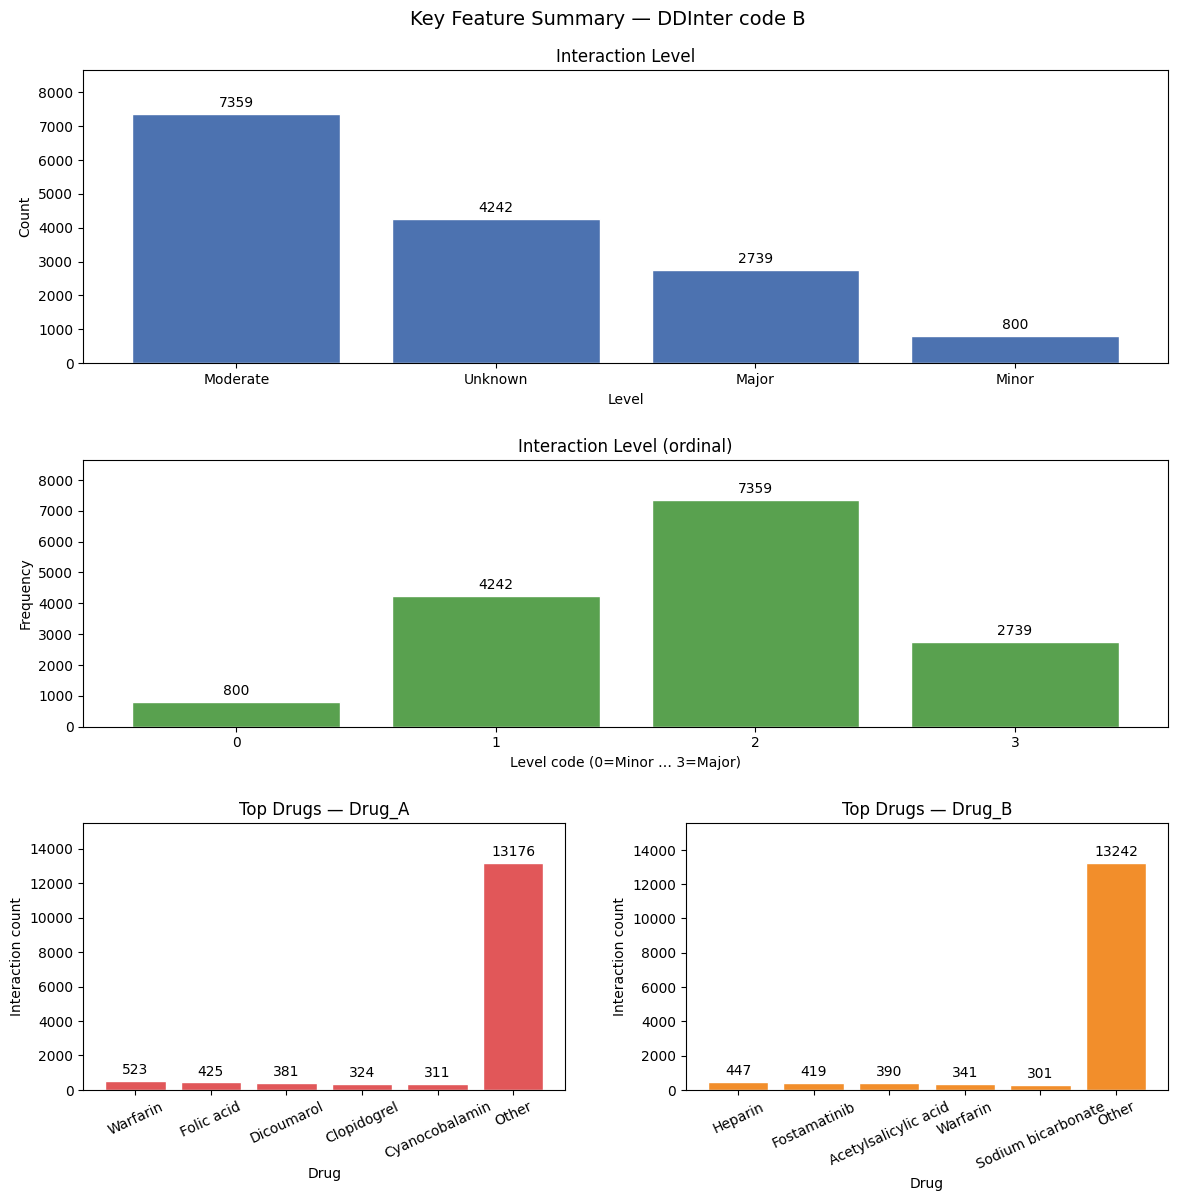

In [59]:
plot_summary(df_raw_b, "Key Feature Summary — DDInter code B")

## Dataset V — `ddinter_downloads_code_V.csv`

Same workflow as dataset B: one-hot unified summary first, then ordinal **`interaction_risk`** and an updated unified table.

In [60]:
df_raw_v = load_dataset(DATASETS["V"])
df_raw_v.head()

ddinter_downloads_code_V.csv: 12,024 rows × 5 columns


,DDInterID_A,Drug_A,DDInterID_B,Drug_B,Level
0,DDInter1,Abacavir,DDInter424,Cobicistat,Moderate
1,DDInter690,Ethanol,DDInter1,Abacavir,Minor
2,DDInter270,Calcium acetate,DDInter582,Dolutegravir,Major
3,DDInter1019,Lamivudine,DDInter424,Cobicistat,Moderate
4,DDInter488,Deferasirox,DDInter582,Dolutegravir,Minor


In [61]:
df_v = encode_level(df_raw_v)
measurement_levels_v = build_measurement_levels(df_v)
df_v.filter(regex=r"^Level_").head()


Encoded shape: 12,024 rows × 8 columns


,Level_Major,Level_Minor,Level_Moderate,Level_Unknown
0,0,0,1,0
1,0,1,0,0
2,1,0,0,0
3,0,0,1,0
4,0,1,0,0


In [62]:
drug_column_overview_v = build_drug_column_overview(df_raw_v, measurement_levels_v)
drug_column_overview_v


,unique_values,measurement_level
column,,
Drug_A,1321,nominal
Drug_B,1352,nominal
Level,4,ordinal


In [63]:
unified_summary_v = build_unified_summary(df_v, measurement_levels_v)
unified_summary_v


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
DDInterID_A,str,nominal,12024,0,1321,NaN,NaN,DDInter771,NaN,NaN,NaN,NaN,<NA>
Drug_A,str,nominal,12024,0,1321,NaN,NaN,Folic acid,NaN,NaN,NaN,NaN,<NA>
DDInterID_B,str,nominal,12024,0,1352,NaN,NaN,DDInter1533,NaN,NaN,NaN,NaN,<NA>
Drug_B,str,nominal,12024,0,1352,NaN,NaN,Promethazine,NaN,NaN,NaN,NaN,<NA>
Level_Major,int64,nominal (binary indicator),12024,0,2,0.243,0.0,0,0.0,1.0,1.0,NaN,<NA>
Level_Minor,int64,nominal (binary indicator),12024,0,2,0.024,0.0,0,0.0,1.0,1.0,NaN,<NA>
Level_Moderate,int64,nominal (binary indicator),12024,0,2,0.537,1.0,1,0.0,1.0,1.0,NaN,<NA>
Level_Unknown,int64,nominal (binary indicator),12024,0,2,0.196,0.0,0,0.0,1.0,1.0,NaN,<NA>


### Updated unified summary — ordinal `interaction_risk`

In [64]:
df_v = add_ordinal_interaction_risk(df_raw_v, df_v)
measurement_levels_v = build_measurement_levels(df_v)
df_v[[INTERACTION_RISK_COL]].head()

,interaction_risk
0,2
1,0
2,3
3,2
4,0


In [65]:
unified_summary_v = build_unified_summary(df_v, measurement_levels_v)
unified_summary_v

,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
DDInterID_A,str,nominal,12024,0,1321,NaN,NaN,DDInter771,NaN,NaN,NaN,NaN,<NA>
Drug_A,str,nominal,12024,0,1321,NaN,NaN,Folic acid,NaN,NaN,NaN,NaN,<NA>
DDInterID_B,str,nominal,12024,0,1352,NaN,NaN,DDInter1533,NaN,NaN,NaN,NaN,<NA>
Drug_B,str,nominal,12024,0,1352,NaN,NaN,Promethazine,NaN,NaN,NaN,NaN,<NA>
interaction_risk,int64,ordinal,12024,0,4,1.999,2.0,2,0.0,3.0,3.0,-0.364,0


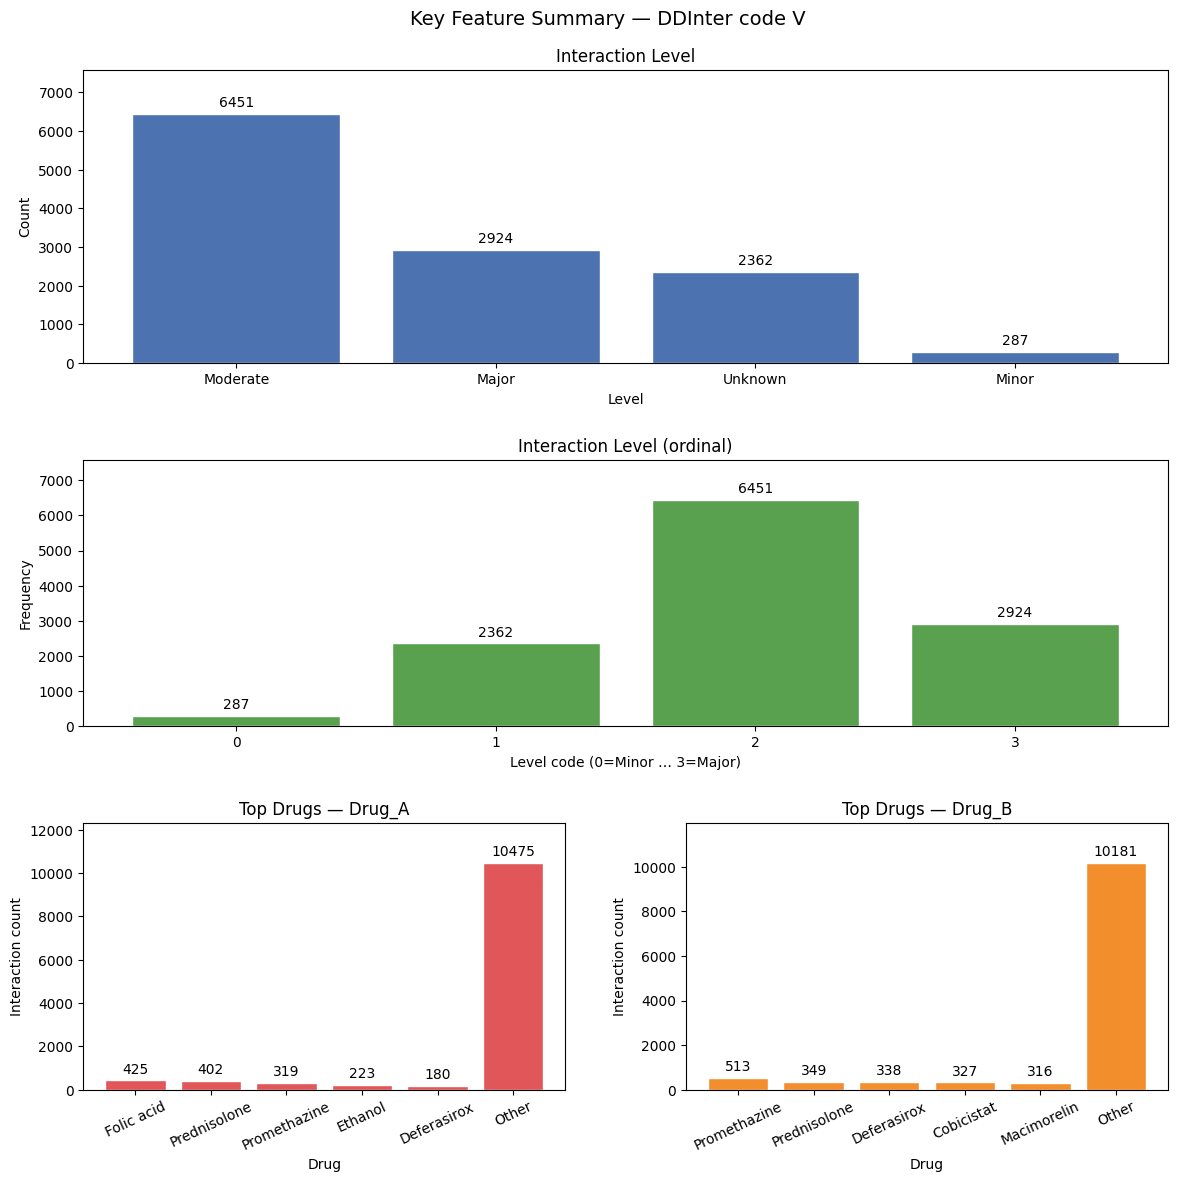

In [66]:
plot_summary(df_raw_v, "Key Feature Summary — DDInter code V")